### PACOTES

In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [6]:

# =========================
# CARREGANDO O CSV
# =========================

df_resumo = pd.read_csv('resumo_features.csv')

# =========================
# AJUSTES
# =========================

# Converte p-valor científico para float
df_resumo['Comparacao_dis_whith'] = pd.to_numeric(
    df_resumo['Comparacao_dis_whith'],
    errors='coerce'
)

# Quanto MENOR o p-valor, MELHOR a feature
# então invertendo:
df_resumo['MannWhitney_Score'] = -np.log10(
    df_resumo['Comparacao_dis_whith'] + 1e-300
)

# Valores absolutos das correlações
df_resumo['Corr_pearson_abs'] = abs(df_resumo['Corr_pearson'])
df_resumo['Corr_spearman_abs'] = abs(df_resumo['Correlacao_spearman'])

# =========================
# MÉTRICAS UTILIZADAS
# =========================

metricas = [

    # MUITO IMPORTANTES
    'Curva ROC',
    'inf_mutua',
    'divergencia_kl',

    # IMPORTANTES
    'Sep_mediana_norm',
    'MannWhitney_Score',

    # COMPLEMENTARES
    'Corr_pearson_abs',
    'Corr_spearman_abs',
    'Var_Prop_Pca',

    # BAIXO PESO
    'Entropia',
    'Qnd_Outliers',

    # QUASE IRRELEVANTE
    'Normalidade'
]

# =========================
# NORMALIZAÇÃO
# =========================

scaler = MinMaxScaler()

df_norm = df_resumo.copy()

df_norm[metricas] = scaler.fit_transform(df_norm[metricas])

# =========================
# SCORE ANTIFRAUDE
# =========================

df_norm['Score_Antifraude'] = (

    # MAIS IMPORTANTES
    df_norm['Curva ROC'] * 0.35 +
    df_norm['inf_mutua'] * 0.20 +
    df_norm['divergencia_kl'] * 0.15 +

    # IMPORTANTES
    df_norm['Sep_mediana_norm'] * 0.10 +
    df_norm['MannWhitney_Score'] * 0.08 +

    # COMPLEMENTARES
    df_norm['Corr_pearson_abs'] * 0.04 +
    df_norm['Corr_spearman_abs'] * 0.03 +
    df_norm['Var_Prop_Pca'] * 0.03 +

    # POUCO IMPORTANTES
    df_norm['Entropia'] * 0.01 +
    df_norm['Qnd_Outliers'] * 0.005 +

    # QUASE IRRELEVANTE
    df_norm['Normalidade'] * 0.005
)

# =========================
# RANKING FINAL
# =========================

ranking = df_norm.sort_values(
    'Score_Antifraude',
    ascending=False
)

# =========================
# RESULTADO
# =========================

pd.set_option('display.max_columns', None)

display(ranking)

# =========================
# SALVANDO
# =========================

ranking.to_csv(
    'ranking_features_antifraude.csv',
    index=False
)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl,Curva ROC,MannWhitney_Score,Corr_pearson_abs,Corr_spearman_abs,Score_Antifraude
13,V14,0.0,0.553865,0.217289,0.361285,1.000000,1.471581e-260,-0.302544,-0.064613,0.984641,1.000000,1.000000,1.000000,0.926501,1.000000,0.957852
11,V12,0.0,0.585371,0.238616,0.391901,0.796989,8.416027e-247,-0.260593,-0.062870,0.917286,0.663488,0.972118,0.946936,0.797689,0.972125,0.854718
9,V10,0.0,0.454295,0.288834,0.242474,0.579452,9.611131e-222,-0.216883,-0.059564,0.908347,0.763357,0.919245,0.850284,0.663475,0.919255,0.812414
16,V17,0.0,0.479250,0.164296,0.189465,0.870823,9.219384e-124,-0.326481,-0.044335,1.000000,0.786255,0.675706,0.472352,1.000000,0.675708,0.750246
10,V11,0.0,0.718112,0.250273,0.019917,0.497847,4.910592e-226,0.154876,0.060143,0.820345,0.483988,0.928507,0.866838,0.473081,0.928514,0.742344
3,V4,0.0,0.717355,0.508575,0.284656,0.415041,3.625904e-248,0.133447,0.063045,0.586806,0.603386,0.974920,0.952203,0.407282,0.974924,0.736164
2,V3,0.0,0.517007,0.587540,0.085872,0.486416,1.211048e-219,-0.192961,-0.059278,0.583784,0.475816,0.914680,0.842183,0.590022,0.914681,0.698551
15,V16,0.0,0.538713,0.176756,0.208973,0.580474,1.808172e-156,-0.196539,-0.049936,0.733854,0.512276,0.765280,0.598510,0.601008,0.765281,0.656122
6,V7,0.0,0.198458,0.381337,0.228481,0.346706,1.464234e-146,-0.187257,-0.048308,0.457887,0.463254,0.739240,0.560292,0.572508,0.739245,0.558938
1,V2,0.0,0.380592,0.702305,0.345377,0.221554,1.650438e-163,0.091289,0.051062,0.366738,0.392804,0.783279,0.625663,0.277834,0.783288,0.539838


### TOP 2

In [10]:
ranking[['Feature', 'Score_Antifraude']].head(2)

,Feature,Score_Antifraude
13,V14,0.957852
11,V12,0.854718


### TOP 3 


In [9]:
ranking[['Feature', 'Score_Antifraude']].head(3)

,Feature,Score_Antifraude
13,V14,0.957852
11,V12,0.854718
9,V10,0.812414


### TOP 5

In [8]:
ranking[['Feature', 'Score_Antifraude']].head(5)

,Feature,Score_Antifraude
13,V14,0.957852
11,V12,0.854718
9,V10,0.812414
16,V17,0.750246
10,V11,0.742344


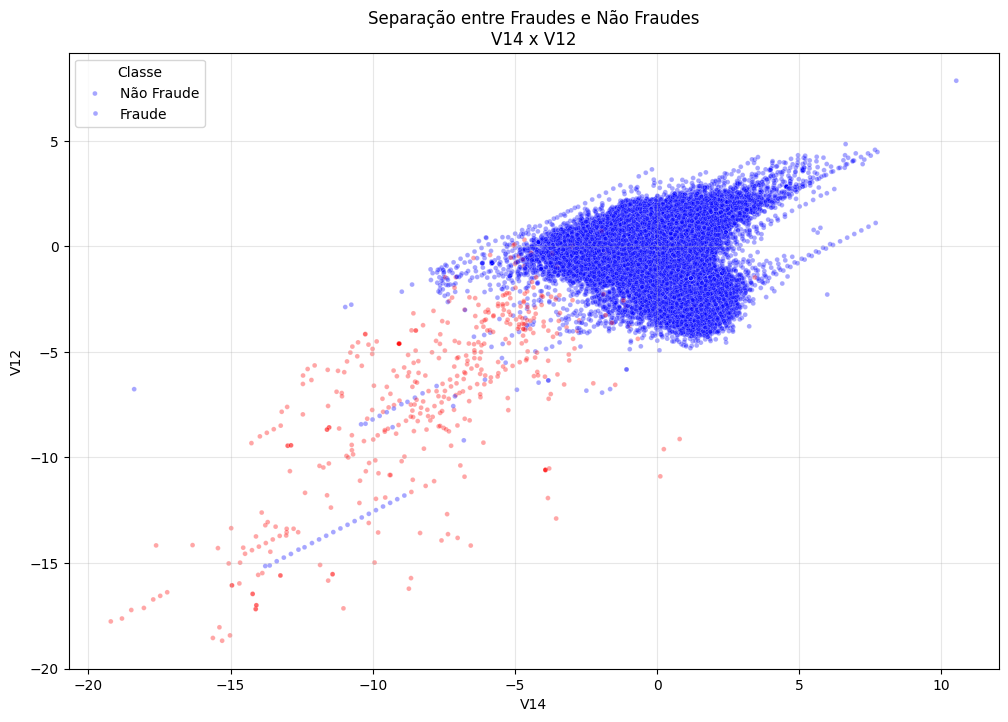

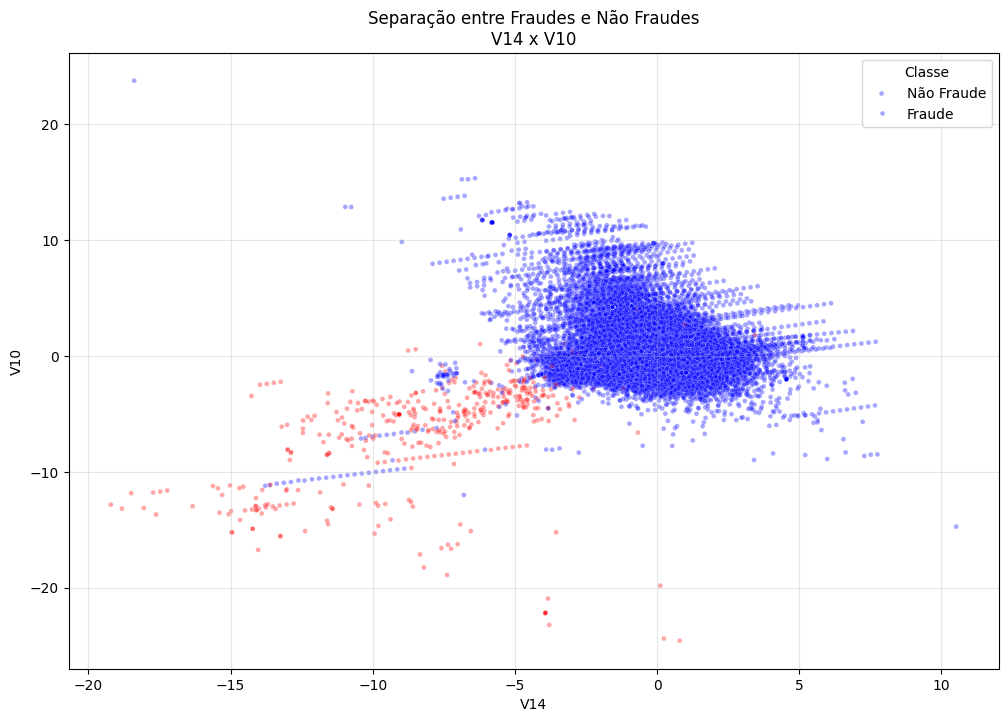

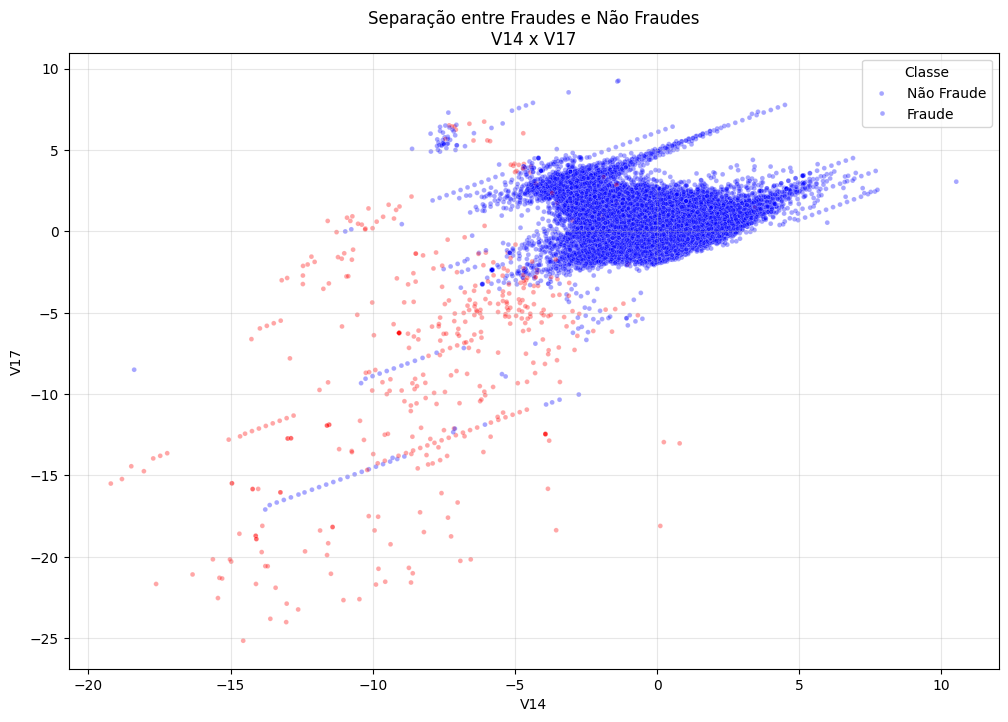

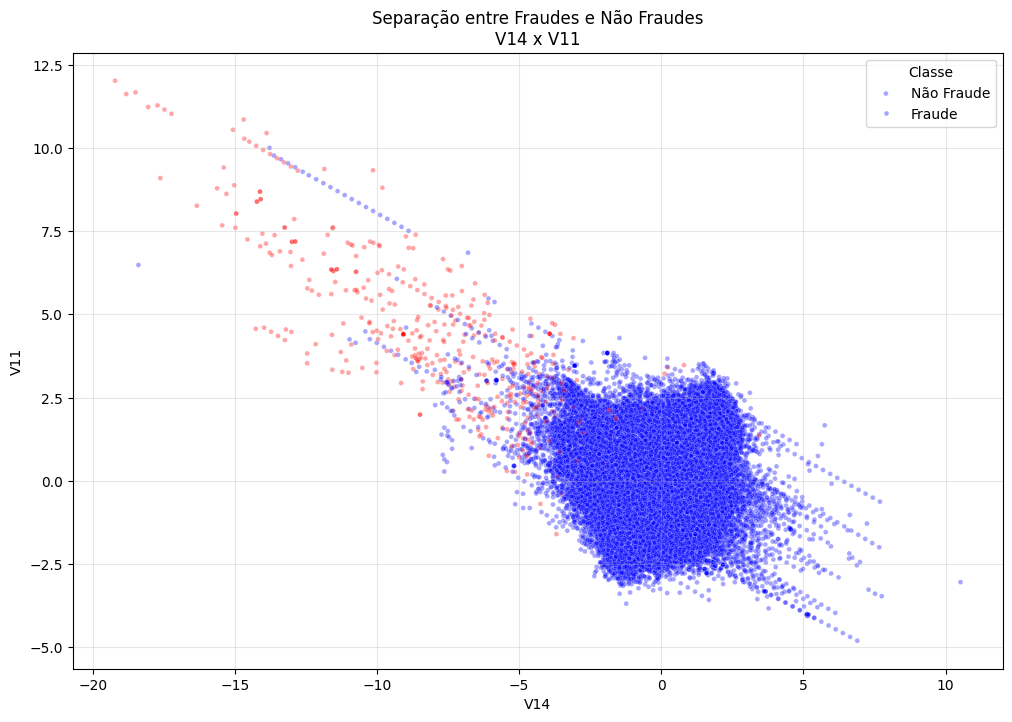

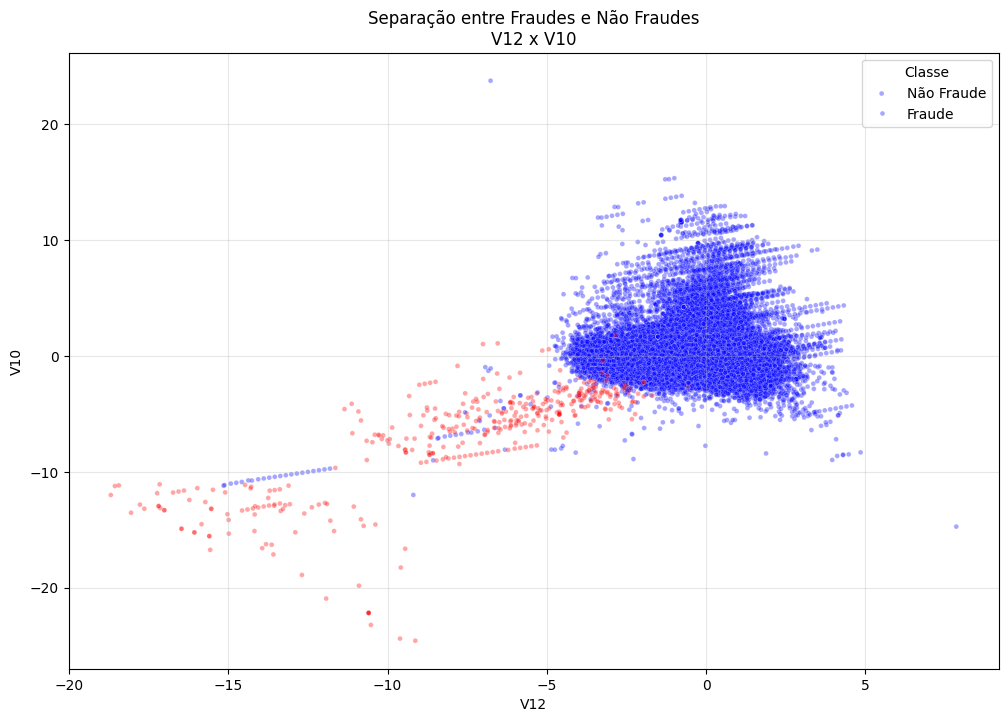

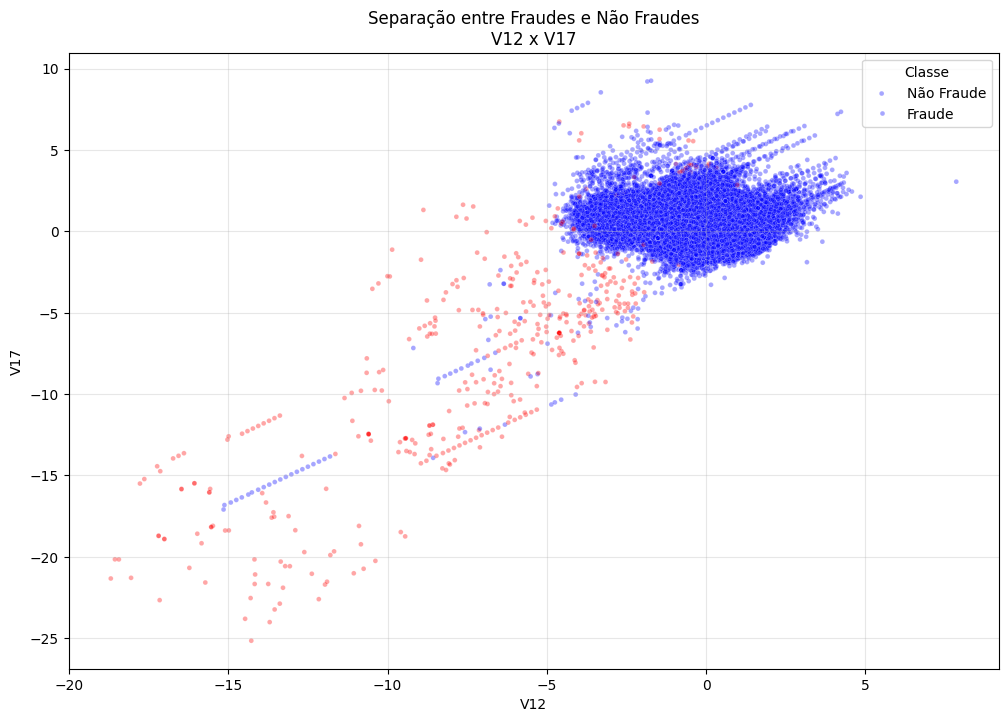

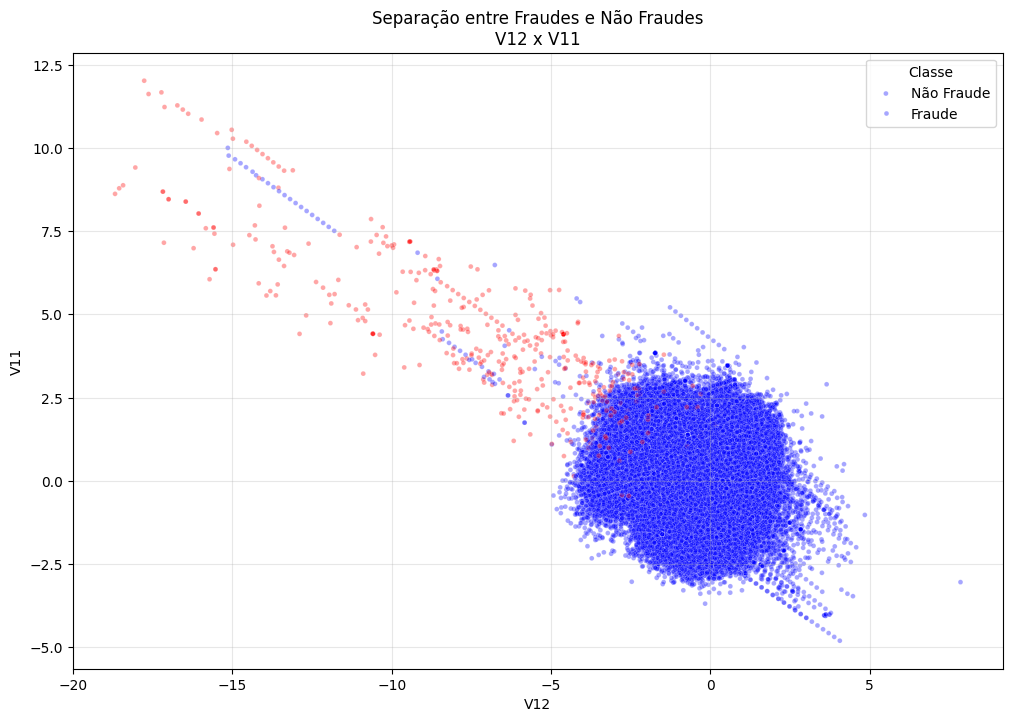

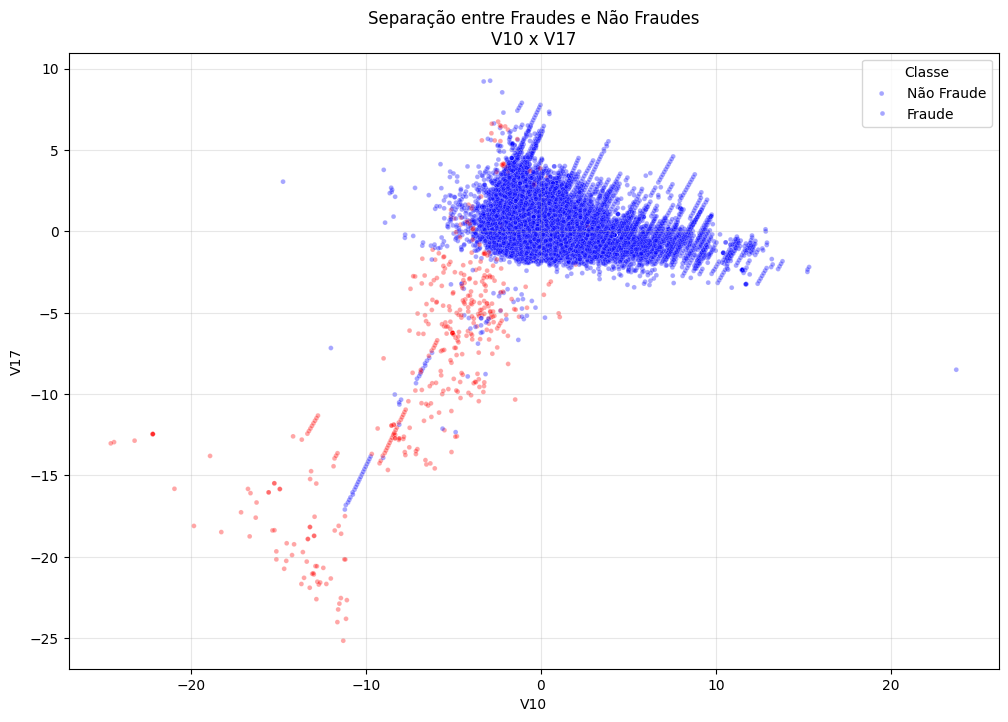

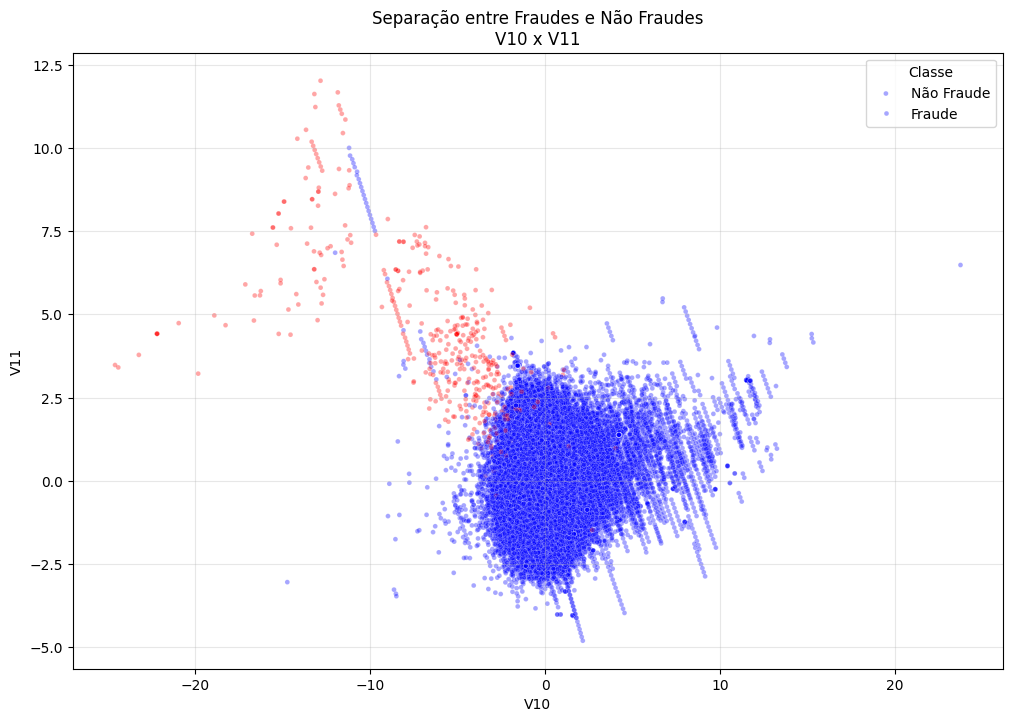

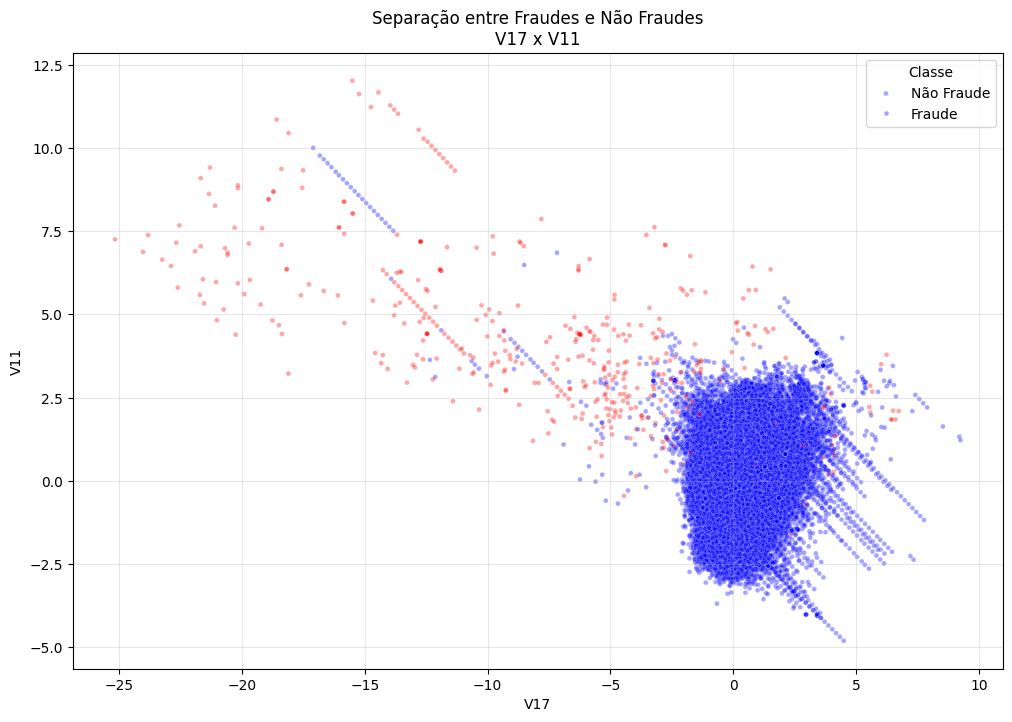

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# =========================
# CARREGANDO O DATASET
# =========================

df = pd.read_csv('creditcard.csv')

# Renomeando target
df.rename(
    columns={'Class': 'status_fraude'},
    inplace=True
)

# =========================
# TOP FEATURES
# =========================

features = ['V14', 'V12', 'V10', 'V17', 'V11']

# =========================
# GERANDO TODAS AS COMBINAÇÕES 2x2
# =========================

combinacoes = list(combinations(features, 2))

# =========================
# PLOTANDO
# =========================

for x_feature, y_feature in combinacoes:

    plt.figure(figsize=(12,8))

    sns.scatterplot(
        data=df,
        x=x_feature,
        y=y_feature,
        hue='status_fraude',
        alpha=0.35,
        s=12,
        palette={
            0: 'blue',
            1: 'red'
        }
    )

    plt.title(
        f'Separação entre Fraudes e Não Fraudes\n{x_feature} x {y_feature}'
    )

    plt.xlabel(x_feature)
    plt.ylabel(y_feature)

    plt.grid(True, alpha=0.3)

    plt.legend(
        title='Classe',
        labels=['Não Fraude', 'Fraude']
    )

    plt.show()